# Meeresspiegelsimulation mit der virtuellen Maschine (Copernicus DEM, GLO-30)

**Autor*in:** Julian Hausmann
**Copyright:** © 2026 Urbetho CF GmbH
**Lizenz:** Dieses Notebook steht unter der [CC BY-NC-SA 4.0 License](https://creativecommons.org/licenses/by-nc-sa/4.0/deed.en).

<div style="text-align: right"><i> Anfänger*innen </i></div>

In diesem Notebook nutzen wir eine virtuell Maschine zum Arbeiten und Einbinden der Satellitendaten. Die Daten liegen dabei auf dem "eo-data" Bucket und über einen "S3FS-Mount" kann auf sie zugegriffen werden. Für den Zugriff brauchen wir deswegen keine komplizierte API-URL-Anfrage, sondern wir können einfach den S3-Pfad in unsere Dateisuche einfügen. Dadurch fühlt es sich so an, als würden wir auf einem lokalen Computer arbeiten und hätten die Daten "wie eine Festplatte" angeschlossen. Wir verwenden das hochauflösende Copernicus DEM (GLO-30) mit einer räumlichen Auflösung von 30m. Die Daten werden über der ostfriesischen Küste in Deutschland heruntergeladen und lokale gespeichert. Auf der Grundlage dieser Daten wird anschließend eine Simulation des Meeresspiegelanstiegs durchgeführt. Letztere findet bereits seit Beginn der Industrialisierung auf Grund steigender globaler Temperaturen statt. Laut [**IPCC**](https://www.geomar.de/entdecken/meeresspiegel) könnte der Meeresspsiegel bis 2300 bis zwischen 0.5m und 15m ansteigen (in Abhängigkeit von den Treibhausgasemissionen). Für moderate Prognosen ist die hohe Auflösung des Copernicus DEM (GLO-30) besonders nützlich, da Dämme und Deiche in die Analyse miteinbezogen werden können. Die Simulation erfolgt schließlich lediglich für einen kleinen Bildausschnitt für die Insel Norderney, um Rechenleistung zu reduzieren. 

**Der Zugriff ist dabei nur über eine VM möglich**. Wie Sie den Zugang zu einer VM erhalten lesen Sie im [**CODE-DE Portfolio**](https://code-de.org/de/portfolio/) unter dem Eintrag Virtuelle Maschinen. Der Zugang beschleunigt die Arbeit mit den Daten, da langwierige Downloads wegfallen. **Sie können diese Analyse auch für andere Küstenorte durchführen, indem Sie an einigen Stellen im Notebook nur wenige Veränderungen vornehmen. Dazu gehören das Einfügen von Koordinaten und anschließend das Auswählen eines geeigneten Bildausschnittes.**

**General Note 1**: Ausführung der Zellen durch pressen des <button class="btn btn-default btn-xs"><i class="icon-play fa fa-play"></i></button> button vom top MENU (oder `Shift` + `Enter`).

**General Note 2**: Falls der Kern nich mehr arbeitet, im the top MENU, klicke <button class="btn btn-default btn-xs"><i class="fa fa-repeat icon-repeat"></i></button> button. Dann, im top MENU, clicke  "Run" aund wähle "Run All Above Selected Cell".

**General Note 3**: Schauen Sie sich im [**FORUM**](https://forum.code-de.org/de/) um oder Kontaktieren Sie den Support! 
<br>

<img src="https://upload.wikimedia.org/wikipedia/commons/thumb/3/38/1880-_Global_average_sea_level_rise_%28SLR%29_-_annually.svg/1920px-1880-_Global_average_sea_level_rise_%28SLR%29_-_annually.svg.png">
     
*Die Abbildung zeigt den globalen Meeresspiegelansteig seit 1880 und wurde von der U.S. Environmental Protection Agency (EPA) auf der Grundlage von Daten der CSIRO 2017 und NOAA 2022 erstellt.*

#### 1. Installieren von uv als Paket- und Projektmanagement-Tool   

Installieren Sie `uv` über einen CURL-Befehl im Terminal:

`curl -LsSf https://astral.sh/uv/install.sh | sh`

**Option A: GitHub geklont**

Wechseln Sie anschließend in den Ordner `Virtuelle-Maschine` innerhalb des geklonten Repositories und führen Sie dort den Synchronisations-Befehl aus: 

`cd notebook-samples/Virtuelle-Maschine`  
`uv sync`

**Option B: Ohne GitHub-Klon**

Wenn Sie das Repository nicht geklont haben, kopieren Sie die Datei `pyproject.toml` in Ihren gewünschten lokalen Ordner. Öffnen Sie das Terminal direkt in diesem Ordner und führen Sie den Befehl aus:

`uv sync`

**Auswählen des Kernels in VS Code (Wichtig für Git-Nutzer)**

Um die Git-Anbindung in VS Code nicht zu verlieren, öffnen Sie bitte weiterhin das **Hauptverzeichnis `notebook-samples`** (und nicht den Unterordner direkt).

1. Öffnen Sie das gewünschte Jupyter Notebook im Ordner `Virtuelle-Maschine`.
2. Klicken Sie oben rechts auf **"Select Kernel"** -> **"Python Environments"**.
3. Wählen Sie die virtuelle Umgebung aus, die auf den Unterordner verweist (angezeigt als **`Virtuelle-Maschine/.venv`**).
4. *Sollte die Umgebung nicht automatisch aufgelistet werden:* Wählen Sie "Enter interpreter path..." und geben Sie den Pfad manuell an (z. B. `Virtuelle-Maschine/.venv/bin/python` unter Linux).

#### 2. Importieren der benötigten Bibliotheken

Viele der unten genannten Bibliotheken mussten nicht installiert werden, weil sie entweder bereits installiert wurden oder zu einer generellen Installation von Python zugehörig sind. Ohne die Bibliotheken ist das folgende Skript nicht ausführbar.  

In [2]:
# Versuche die benötigten Pakete zu installieren
try:
    # Liste aller benötigter Pakete
    import os
    import matplotlib.pyplot as plt
    import rasterio
    import numpy as np
    from rasterio.windows import Window
    import glob
    from scipy.ndimage import binary_propagation
    from matplotlib.patches import Polygon

    # Text Ausgabe
    print("Erfolgreiche Installation aller benötigter Pakete.")

except:

    # Text Ausgabe
    print("Nicht erfolgreiche Installation aller benötigter Pakete")

Erfolgreiche Installation aller benötigter Pakete.


#### 3. Finden der Datensätze

Wir finden unsere Copernicus DEM (GLO-30) Szene, indem wir hier einfach den S3-Pfad aus dem CODE-DE Explorer kopieren. Dadurch weiß unser System genau, wo es über den "S3FS-Mount" im "eo-data"-Bucket nach der Satellitenszene suchen muss. Die Szene enthält dabei mehr als nur eine ".tif"-Datei, sondern ebenfalls Metadaten usw. Damit wir das teilweise komplexe Speichersystem der Copernicus DEM (GLO-30)-Datensätze nicht vollständig verstehen müssen, verwenden wir eine Suche auf der Grundlage der glob Bibliothek und dem Suchmuster "DEM.tif", dass nur in dem gesuchten TIF-Bild enthalten ist. 

In [3]:
# Verzeichnis für die Suche definieren
search_directory = "/eodata/auxdata/CopDEM/COP-DEM_GLO-30-DGED/DEM1_SAR_DGE_30_20110408T171540_20130501T171033_ADS_000000_t1G8.DEM"  # Ändern Sie das Verzeichnis zu Ihrem Root-Verzeichnis

# Suchmuster für die Datei definieren (hier nach Dateien suchen, die mit 'DEM.tif' enden)
file_pattern = "**/*DEM.tif"  # Suchmuster

# Verwenden von glob, um alle Dateien im Verzeichnis zu finden, die dem Suchmuster entsprechen
result = glob.glob(os.path.join(search_directory, file_pattern), recursive=True)

# Überprüfen, ob eine Datei gefunden wurde
if result:
    # Wenn eine Datei gefunden wurde, Ausgabe des Pfades der ersten Datei
    print(f"Datei gefunden: {result[0]}")
else:
    # Wenn keine Datei gefunden wurde, Ausgabe einer entsprechenden Nachricht
    print("Datei nicht gefunden.")

Datei gefunden: /eodata/auxdata/CopDEM/COP-DEM_GLO-30-DGED/DEM1_SAR_DGE_30_20110408T171540_20130501T171033_ADS_000000_t1G8.DEM/Copernicus_DSM_10_N53_00_E007_00/DEM/Copernicus_DSM_10_N53_00_E007_00_DEM.tif


#### 4. Definieren eines Bildausschnitt

Um die Rechenleistung und Zeit für die Meeresspiegelanstiegssimulation zu reduzieren soll nur ein Ausschnitt des gespeicherten Copernicus DEM (GLO-30)-Datensatzes erstellt werden. Dafür lassen wir uns zunächst das gesamte Bild anzeigen. Im Gegensatz zum Original DEM (links) lassen sich auf dem Histogram-Stretched DEM besser die Strukturen der Landoberfläche der ostfriesischen Küste erkennen (rechts). Um den Bildausschnitt zu wählen, betrachten wir folgend also das rechte Bild.

Norderney ist bei x = 200 und y = 800 zu erkennen und lässt sich über eine West-Ost-Ausdehnung von 750 Pixeln und eine Nord-Süd-Ausdehnung von 500 Pixeln beschreiben. Die Zählung der Pixel beginnt oben links bei 0 und verläuft von links nach recht bzw. oben nach unten. **Wenn Sie sich für einen anderen Küstenort entschieden haben, werden Sie entsprechend andere Koordinaten als passend definieren.**

/tmp/ipykernel_72053/2201225818.py:3: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  dem = dataset.read(1)  # Das erste Band (Höhenwerte) des DEM laden


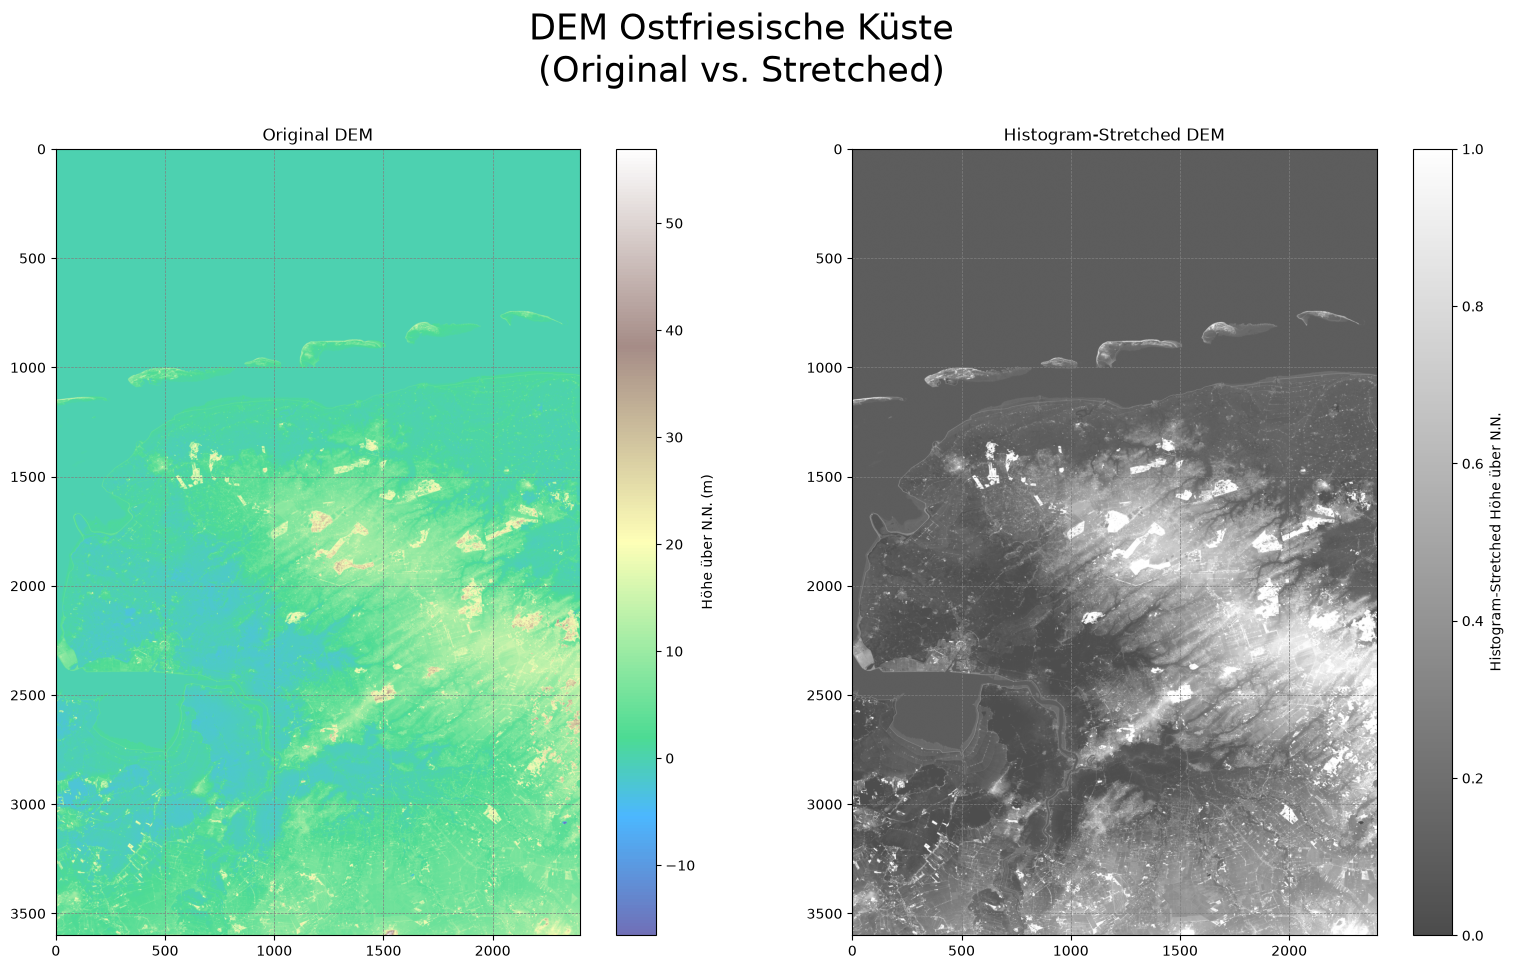

In [4]:
# DEM (Digitales Höhenmodell) laden
with rasterio.open(result[0]) as dataset:
    dem = dataset.read(1)  # Das erste Band (Höhenwerte) des DEM laden
    transform = dataset.transform  # Transformation des Koordinatensystems des DEM
    nodata = dataset.nodata  # NoData-Werte aus dem Dataset extrahieren
    
# NoData-Werte maskieren (ersetzen durch NaN)
dem = np.where(dem == nodata, np.nan, dem)

# Prozentränge auswählen, um extreme Werte zu begrenzen
p2, p98 = np.nanpercentile(dem, (2, 98))  # 2. und 98. Perzentil des DEM berechnen

# Lineares Strecken der DEM-Werte
dem_stretched = np.clip((dem - p2) / (p98 - p2), 0, 1)  # Strecken der Werte auf den Bereich [0, 1]

# Erstellen der Subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 10))  # Zwei Subplots nebeneinander

# Originales DEM plotten
im1 = axes[0].imshow(dem, cmap="terrain", alpha=0.7)  # Original DEM anzeigen mit Farbschema "terrain"
axes[0].set_title("Original DEM", fontsize=12)  # Titel für das erste Diagramm
axes[0].grid(True, color='gray', linestyle='--', linewidth=0.5)  # Gitterlinien hinzufügen

# Farbskala zum ersten Subplot hinzufügen
cbar1 = plt.colorbar(im1, ax=axes[0], orientation='vertical', label="Höhe über N.N. (m)")  # Vertikale Farbskala mit Bezeichnung

# Histogramm-strecktes DEM plotten
im2 = axes[1].imshow(dem_stretched, cmap="gray", alpha=0.7)  # Streckung des DEM anzeigen in Graustufen
axes[1].set_title("Histogram-Stretched DEM", fontsize=12)  # Titel für das zweite Diagramm
axes[1].grid(True, color='gray', linestyle='--', linewidth=0.5)  # Gitterlinien hinzufügen

# Farbskala zum zweiten Subplot hinzufügen
cbar2 = plt.colorbar(im2, ax=axes[1], orientation='vertical', label="Histogram-Stretched Höhe über N.N.")  # Vertikale Farbskala für das gestreckte DEM

# Optional: Einen allgemeinen Titel für das gesamte Diagramm hinzufügen
fig.suptitle("DEM Ostfriesische Küste\n(Original vs. Stretched)", fontsize=25, y=0.95)  # Gesamtüberschrift

# Layout anpassen, damit der Titel und die Subplots gut platziert sind
plt.tight_layout(rect=[0, 0, 1, 0.93])  # Erhöht den Abstand oben, um Platz für die Gesamtüberschrift zu schaffen

# Das Diagramm anzeigen
plt.show()

#### 5. Öffnen des Ausschnitts

Aus ermittelten Werten für Norderney lässt sich der Ausschnitt als `window = (200, 800, 750, 500)` definieren. **Bei entsprechend anderen Koordinaten für einen anderen Küstenort, werden diese für das window eingefügt.** Wir zeigen den Ausschnitt auf dem Copernicus DEM (EEA-10)-Datensatz mit der kleineren Auflösung mit einem roten Kasten an (links). Rechts sehen wir dagegen nur den Ausschnitt von Norderney. Der kleinere Bildausschnitt der Anzeige rechts erlaubt uns nun auch die Original Höhenwerte zu nutzen bei gleichzeitig klaren Landschaftsstrukturen. Links verwenden wird nachwievor die ge-stretchten Pixelwerte.

/tmp/ipykernel_72053/352748834.py:22: DeprecationWarning: Setting the shape on a NumPy array has been deprecated in NumPy 2.5.
As an alternative, you can create a new view using np.reshape (with copy=False if needed).
  dem_window = dataset.read(1, window=Window(col_off, row_off, width, height))


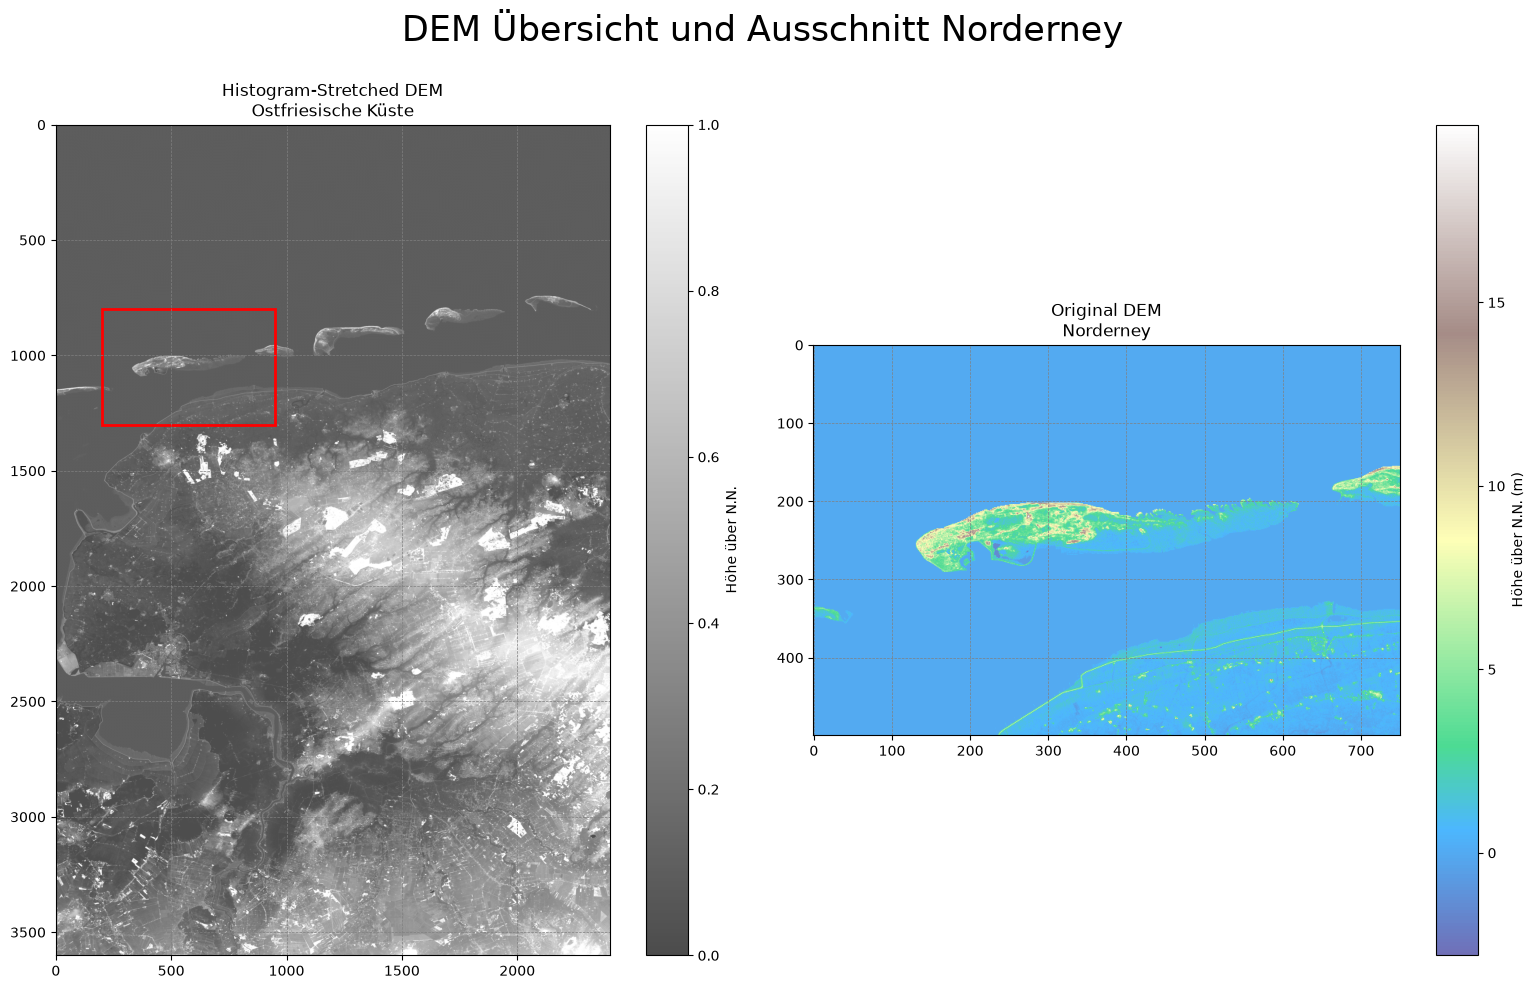

In [5]:
# Definieren des Ausschnittsfensters (Spaltenversatz, Zeilenversatz, Breite, Höhe)
window = (200, 800, 750, 500)  # (col_off, row_off, width, height)

# Entpacken des Fensters in einzelne Variablen
col_off, row_off, width, height = window

# Berechnen der Pixel-Koordinaten der Ecken des Fensters
corners_px = [
    (col_off, row_off),                       # obere linke Ecke
    (col_off + width, row_off),               # obere rechte Ecke
    (col_off + width, row_off + height),      # untere rechte Ecke
    (col_off, row_off + height),              # untere linke Ecke
    (col_off, row_off)                        # zurück zur oberen linken Ecke (um das Polygon zu schließen)
]

# Erstellen des Polygons (Ausschnittsfenster)
poly = Polygon(corners_px, closed=True, edgecolor='red', facecolor='none', linewidth=2)

# Laden des DEM
with rasterio.open(result[0]) as dataset:
    # Laden des DEM-Ausschnitts gemäß dem definierten Fenster
    dem_window = dataset.read(1, window=Window(col_off, row_off, width, height))
    transform = dataset.transform  # Transformation des Koordinatensystems
    nodata = dataset.nodata  # NoData-Werte des DEM
    
    # Maskieren der NoData-Werte (ersetzen durch NaN)
    dem_window = np.where(dem_window == nodata, np.nan, dem_window)

# Erstellen der Subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 10))

# Plotten des gesamten gestreckten DEM
im1 = axes[0].imshow(dem_stretched, cmap="gray", alpha=0.7)  # Anzeige des gestreckten DEM
axes[0].grid(True, color='gray', linestyle='--', linewidth=0.5)  # Gitterlinien hinzufügen
axes[0].set_title("Histogram-Stretched DEM\nOstfriesische Küste", fontsize=12)  # Titel für das erste Diagramm
axes[0].add_patch(poly)  # Das Polygon zum ersten Plot hinzufügen (zeigt das Ausschnittsfenster)
cbar1 = plt.colorbar(im1, ax=axes[0], orientation='vertical', label="Höhe über N.N.")  # Farbskala hinzufügen

# Plotten des DEM für Norderney im definierten Ausschnitt
im2 = axes[1].imshow(dem_window, cmap="terrain", alpha=0.7)  # Anzeige des Ausschnitts von Norderney
axes[1].set_title("Original DEM\nNorderney", fontsize=12)  # Titel für das zweite Diagramm
axes[1].grid(True, color='gray', linestyle='--', linewidth=0.5)  # Gitterlinien hinzufügen
cbar1 = plt.colorbar(im2, ax=axes[1], orientation='vertical', label="Höhe über N.N. (m)")  # Farbskala für Norderney hinzufügen

# Optional: Einen allgemeinen Titel für das gesamte Diagramm hinzufügen
fig.suptitle("DEM Übersicht und Ausschnitt Norderney", fontsize=25, y=0.97)  # Gesamtüberschrift

# Layout anpassen, damit der Titel und die Subplots gut platziert sind
plt.tight_layout(rect=[0, 0, 1, 0.93])  # Erhöht den Abstand oben, um Platz für die Gesamtüberschrift zu schaffen

# Das Diagramm anzeigen
plt.show()

#### 6.  Meeresspiegelsimulation

Durch den menschengemachten Klimawandel ist der Meeresspiegel bereits um 20cm angestiegen. Laut Prognose des IPCC hängt der zukünftige Anstieg des Meeresspiegels von den derzeitigen und zukünftigen globalen Treibhausgasemissionen ab. Die Emissionen bis 2100 sind dabei entscheidend, um Vorhersagen bis zum Jahr 2300 zu treffen. Abbildung 1a werden verschiedene Emissionsszenarien dargestellt - SSP1-1.9 stellen das Best-Case Szenario mit ambitioniertem Klimaschutz nach dem Paris Agreement dar während SSP5-8.5 den Wort-Case beschreiben. Die Zahlen entsprechen dabei nicht dem Temperaturanstieg. SSP5-8.5 steht für einen Temperaturanstieg von +4.4°C und SSP1-1.9 für ca. 1+1.4°C. Im Best-Case wird ein Meeresspiegelanstieg von 0.5m bis 3.2m für 2300 vorhergesagt (siehe Abbildung 1c). Im schlimmsten Fall, wenn die Emissionen nicht kontrolliert werden, steht ein Anstieg von 2m bis 7m bevor. Es kann auf Grund einer Vielzahl von Unsicherheiten ein Anstieg von 15m nicht ausgeschlossen werden.

<img src="https://www.geomar.de/fileadmin/_processed_/1/0/csm_IPCC_AR6_fig_SPM_8_62645245d8.png">

*Die Abbildungen wurden vom GEOMAR Helmholtz-Zentrum für Ozeanforschung Kiel (2025) auf der Grundlage des 6. Berichts des IPCC erstellt.*

Wir wollen uns eine Karte von Norderney anzeigen lassen, die die Überflutungsfläche bei einem Meeresspiegelanstieg darstellt. Die Karten bezieht Dämme und Deiche als Schutzwälle mit ein, mögliche Dammbrüche können jedoch nicht berechnet werden. 

Ausgehend von der oberen linken Ecke wird das gesammte Bild "überflutet". All Pixel die mit dem Pixel in der oberen linken Ecke verbunden sind werden konsekutiv als überflutet gelabeled und in der Karte blau angezeigt. Pixel, die unter der Flutschwelle von z.B. 0.2m oder 0.5m liegen, jedoch von einem Deich geschützt werden, werden dadurch ignoriert. 

Bis zu 3.2m Meeresspiegelanstieg bleibt das Festland größtenteils geschützt auf Grund der Deiche. Die Insel Norderney verliert maßgeblich an Fläche bei einem Anstieg von 2m Anstieg. Ab 7m Anstieg helfen die Deiche nicht und das Festland wird überflutet. Die Insel enthält Erhebungen von über 7m, die nicht geflutet würden. Ein Großteil der Insel wäre trotzdem überschwemmt. Bei 15m, im schlimmsten vom IPCC berechneten Fall bleibt keine Fläche übrig.

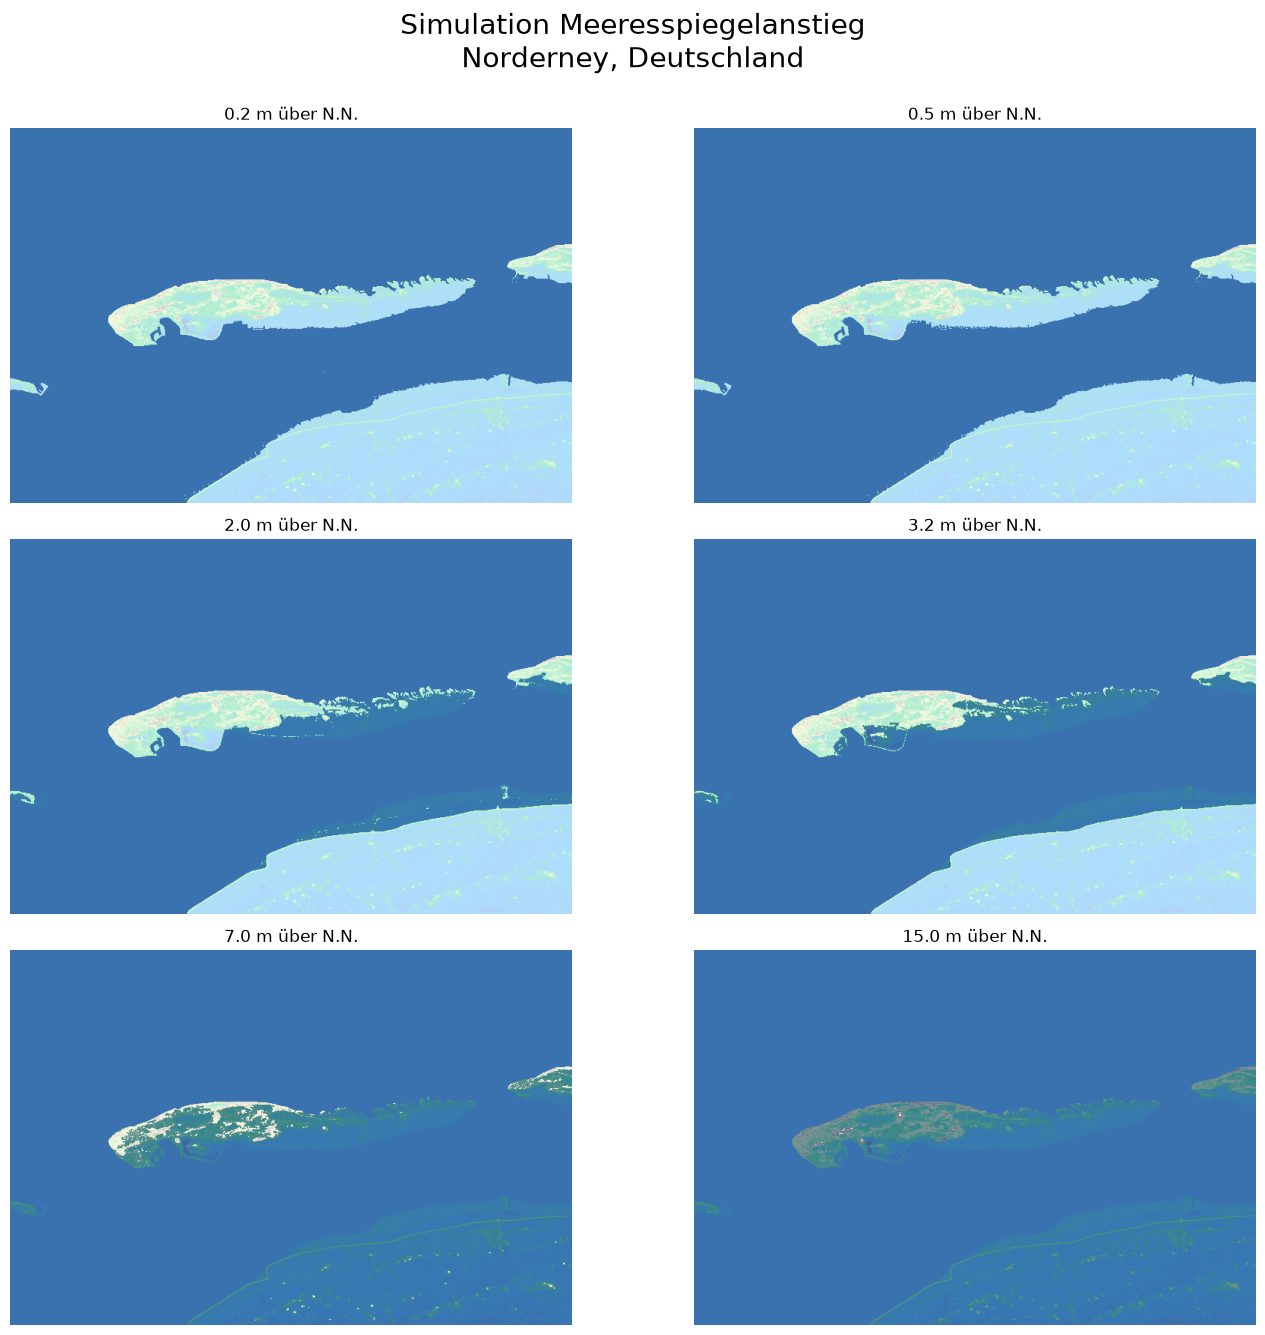

In [6]:
# Liste der Überflutungsstufen in Metern
flood_level_list = [0.20, 0.5, 2.00, 3.20, 7.00, 15.00]

# Erstellen einer Figur mit 3 horizontalen Subplots (2 Zeilen, 3 Spalten)
fig, axes = plt.subplots(3, 2, figsize=(14, 14))  # (Zeilen, Spalten)
axes = axes.flatten()  # Umwandeln der Achsen in ein flaches Array, um leichter darauf zugreifen zu können

# Schleife über jede Überflutungsstufe
for i, flood_level in enumerate(flood_level_list):

    # Identifizieren des anfänglichen Überflutungsbereichs (Gebiet, das unterhalb der Überflutungsstufe liegt)
    flood_mask = dem_window < flood_level

    # Setze Startpunkt (x=0, y=0) für die Flut
    seed = np.zeros_like(flood_mask, dtype=bool)
    seed[0, 0] = True  # Setze den Startpunkt in der oberen linken Ecke

    # Starte binäre Ausbreitung nur innerhalb der flood_mask, ausgehend vom Startpunkt
    flood_extent = binary_propagation(seed, mask=flood_mask)

    # Plotten auf der aktuellen Achse (Subplot)
    ax = axes[i]
    ax.imshow(dem_window, cmap="terrain", alpha=0.6)  # Anzeige des DEM mit Transparenz
    ax.imshow(flood_extent, cmap="Blues", alpha=0.5)  # Anzeige der überfluteten Gebiete
    ax.set_title(f"{str(flood_level)[0:4]} m über N.N.", fontsize=12)  # Titel für jede Stufe
    ax.axis("off")  # Optional: Entfernen der Achsenbeschriftungen

# Hinzufügen eines Titels für die gesamte Figur
fig.suptitle("Simulation Meeresspiegelanstieg\nNorderney, Deutschland", fontsize=20, y=0.95)
plt.tight_layout(rect=[0, 0, 1, 0.95])  # Genügend Platz für den Gesamttitel lassen
plt.show()  # Anzeige der Grafik